# 04 · Reproducing Canciani 2022 — EKF38 with online calibration
38-state tightly-coupled filter (Pinson INS + online T-L + FOGM + vector). Comparison of **loosely-coupled** (static calibration) vs **tightly-coupled** (in-flight calibration).

⚠️ The F-16 flight data from the paper is non-public — we demonstrate the method on public SGL data (Cessna). We emulate the F-16 conditions (stochastic field drift) with the optional `inject_drift`.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


In [2]:
from magnavlab.experiments import CancianiConfig, run_canciani
from IPython.display import Image
out = run_canciani(CancianiConfig(make_plots=True))
print(out['drift_info'], '| batch T-L residual =', round(out['tl_resid'],1), 'nT')
for name, m in out['metrics'].items():
    print(f"{name:9s} DRMS={m['drms']:8.1f} m")
mt, ml = out['metrics']['tightly']['drms'], out['metrics']['loosely']['drms']
print(f'improvement tightly vs loosely: {100*(1-mt/ml):.0f}%')

body-field drift σ=0.6 nT/√s (~78 nT) | batch T-L residual = 35.8 nT
INS       DRMS=  2467.6 m
loosely   DRMS=   103.8 m
tightly   DRMS=    56.6 m
improvement tightly vs loosely: 45%


## N/E errors (like Fig. 12–15 in the paper)

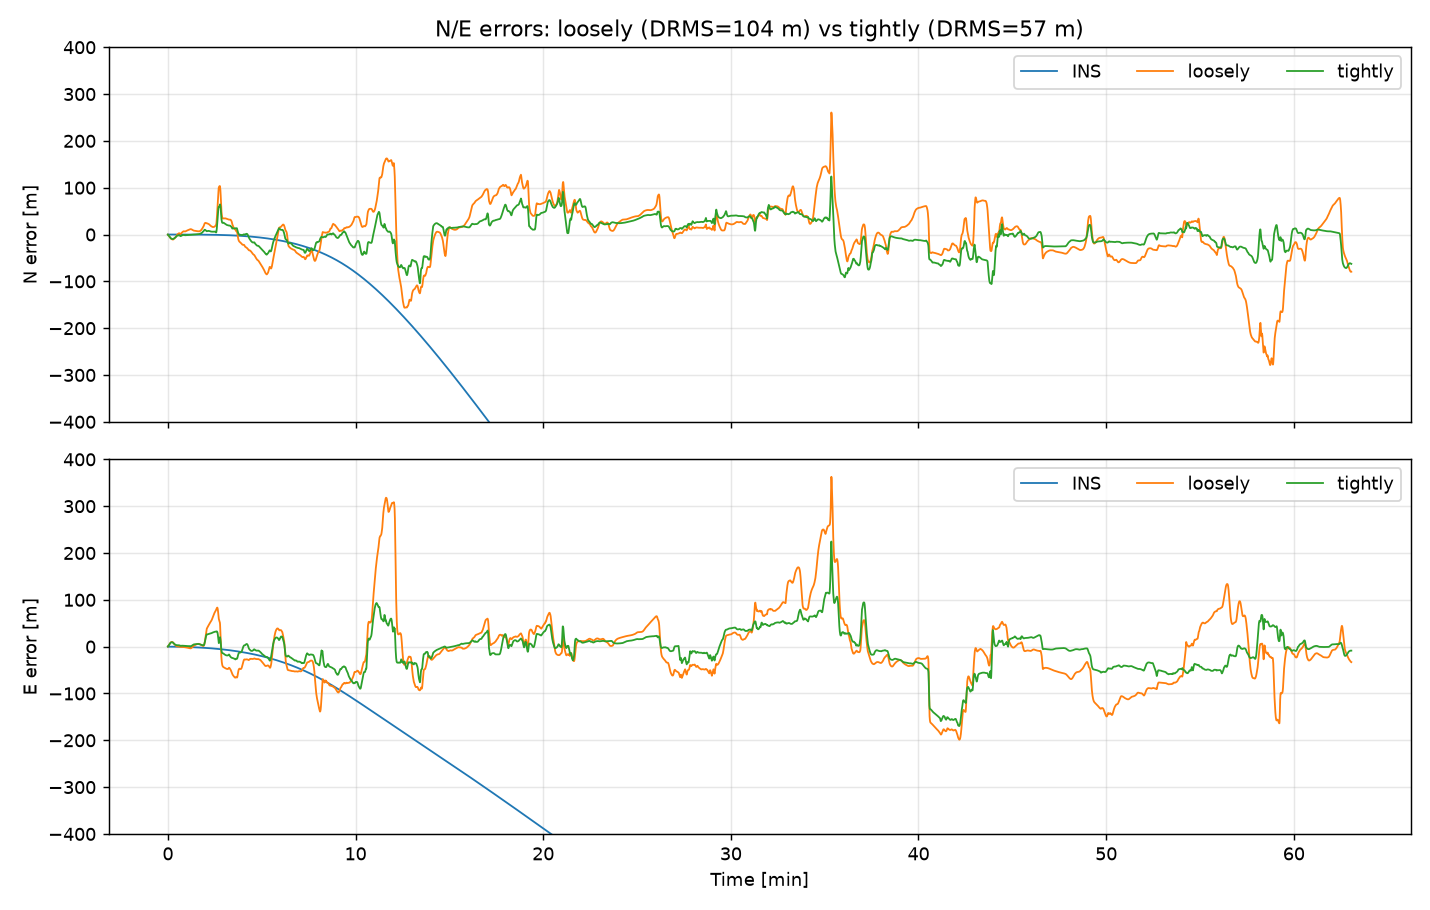

In [3]:
Image('outputs/ekf38_NE_errors.png')

## Online calibration — trace of T-L coefficients

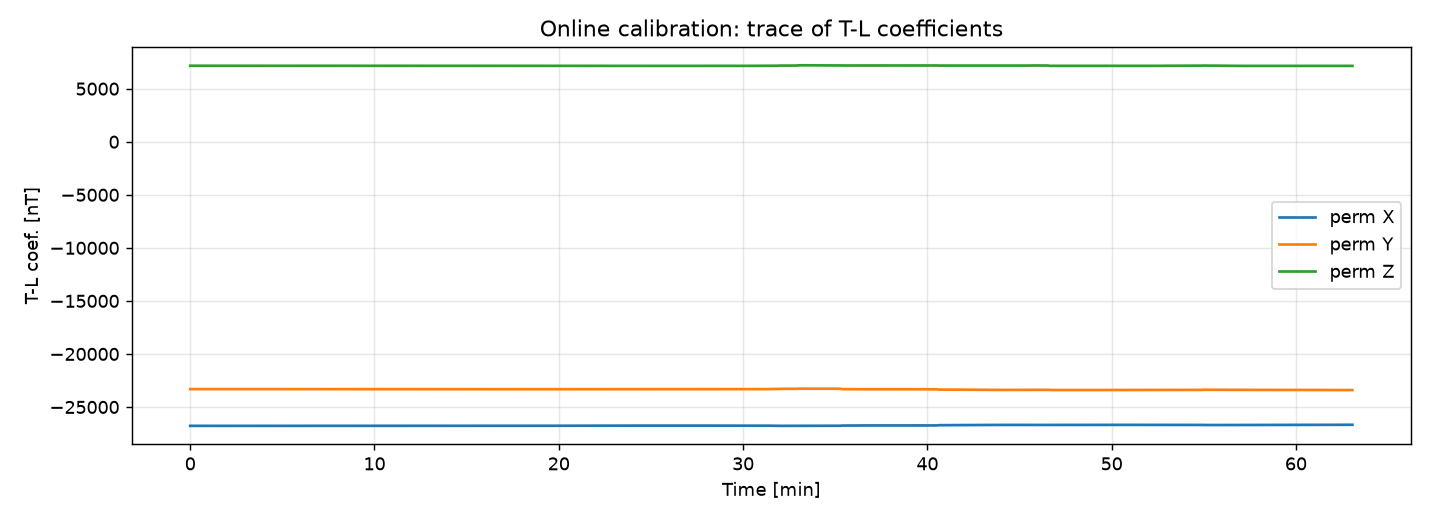

In [4]:
Image('outputs/ekf38_TL_online.png')

The result on SGL data (loosely ~102 m, tightly ~57 m, ~45%) qualitatively matches Table I from the paper (F-16: 111 m → 59 m, ~47%).